# Truth tables and state machines: vehicle gear-selection logic

A modern automatic transmission needs to refuse illegal gear shifts. You cannot select Reverse at 80 km/h; you cannot shift Drive → Reverse without going through Neutral; you cannot leave Park without a foot on the brake. Two separate layers enforce that: a **combinational** *eligibility* table that says "given the current pedal/speed conditions, which gears would even be legal to enter?", and a **sequential** *state machine* that says "given the current gear and the driver's request, which target gears can I actually transition to next?". Get either layer wrong and you ship a recall.

We use the artifact to walk the T-119 `TruthTable` API end-to-end (builder, completeness checker, CSV round-trip, callable row outputs) and feed its output into a `StateMachineBuilder`-built four-state FSM with prioritized transition guards. We close on a deliberate guard violation (Drive → Reverse with no intervening Neutral) and use `analyze_phase_activity` to catch the silent failure mode it produces.

> **Reading time:** ~25 minutes. **Runtime on CPU:** ~30 seconds end-to-end.


## Prerequisites

* Working knowledge of `DiagramBuilder` + `simulate` (covered in [`primitives.ipynb`](primitives.ipynb)).
* Familiarity with discrete-time `LeafSystem` patterns. We re-use the same scalar-input/output idioms as [`multirate_controller.ipynb`](multirate_controller.ipynb) and [`unit_safe_wiring.ipynb`](unit_safe_wiring.ipynb).
* Some intuition about finite-state machines (Mealy/Moore distinction, transition priority). The [Wikipedia article on UML state machines](https://en.wikipedia.org/wiki/UML_state_machine) is enough.

The two APIs we exercise live at:

| Symbol                  | Module                                    |
|-------------------------|-------------------------------------------|
| `TruthTable`            | `jaxonomy.library.logic` (re-exported from `jaxonomy.library`) |
| `TruthTableBuilder`     | `jaxonomy.library.logic` |
| `StateMachineBuilder`   | `jaxonomy.framework.state_machine_builder` (re-exported from `jaxonomy`) |
| `StateMachine`          | `jaxonomy.library.state_machine` |
| `analyze_phase_activity`| `jaxonomy.diagnostics` |


In [1]:
import csv
import io
import os
import tempfile
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import jaxonomy
from jaxonomy import DiagramBuilder, SimulatorOptions, StateMachineBuilder, simulate
from jaxonomy.diagnostics import analyze_phase_activity
from jaxonomy.framework import LeafSystem
from jaxonomy.library import Constant, Demux, TruthTable

# Reproducibility — we do not actually need RNG for this notebook, but the
# convention from the sibling tutorials is to set one seed near the top.
PRNG_SEED = 20260516
_ = jax.random.PRNGKey(PRNG_SEED)


## §1. The two layers

We split the gear controller into a combinational layer and a sequential layer because the two are orthogonal:

1. **Eligibility (combinational, stateless).** A pure function of the *current* sensor reading:

   $$
   \mathbf{e}(t) \;=\; f_\mathrm{eligible}\!\bigl(\,b(t),\,s(t),\,\mathbf{r}(t)\,\bigr) \in \{0,1\}^{4}
   \tag{1}
   $$

   where $b \in \{0,1\}$ is the brake pedal (1 = pressed), $s \in \{0,1\}$ is the *vehicle-stopped* sensor (1 = $|v| < v_\mathrm{thresh}$), $\mathbf{r}(t) \in \{P,R,N,D\}$ is the driver's requested gear, and $\mathbf{e} = (e_P, e_R, e_N, e_D)$ is the four-vector of "is this gear legal *right now*?" flags. The function depends only on the present input — no memory.

2. **Mode (sequential, stateful).** A four-state Mealy machine over $g(t) \in \{P,R,N,D\}$ whose transitions are guarded by the eligibility vector AND the driver request:

   $$
   g(t^{+}) = \begin{cases}
       r & \text{if } e_r \wedge \text{guard}_{g(t) \to r}\bigl(b, s\bigr) \\
       g(t) & \text{otherwise}
   \end{cases}
   \tag{2}
   $$

   The state machine enforces *sequential* constraints — e.g. there is no Drive → Reverse transition in the graph, so even when the driver yanks the shifter from D to R the gear stays at D until the car visits N first.

Concretely, the inputs and outputs:

| Symbol         | Meaning                                       | Domain          |
|----------------|-----------------------------------------------|-----------------|
| $b$            | Brake pedal pressed                            | $\{0,1\}$       |
| $s$            | Vehicle stopped ($|v| < v_\mathrm{thresh}$)    | $\{0,1\}$       |
| $r$            | Driver requested gear                          | $\{P,R,N,D\} \cong \{0,1,2,3\}$ |
| $e_P, e_R, e_N, e_D$ | Per-gear eligibility flag                | $\{0,1\}$       |
| $g$            | Currently engaged gear                         | $\{P,R,N,D\}$   |

The driver request $r$ has four levels, which we encode in two bits $(r_1, r_0)$: $P=(0,0)$, $R=(0,1)$, $N=(1,0)$, $D=(1,1)$. The eligibility table therefore has four boolean inputs — $b, s, r_1, r_0$ — and one four-vector output. With $2^4 = 16$ input combinations, the completeness checker is tractable to inspect by eye.


In [2]:
# Gear-index conventions used throughout the notebook.
# State-machine numeric outputs are floats (the action language only
# assigns numeric values to outputs), so we keep these as floats too.
GEAR_P, GEAR_R, GEAR_N, GEAR_D = 0.0, 1.0, 2.0, 3.0
GEAR_NAMES = ["P", "R", "N", "D"]

# Driver-request two-bit encoding: (r1, r0) per the table above.
REQUEST_BITS = {
    "P": (False, False),
    "R": (False, True),
    "N": (True, False),
    "D": (True, True),
}

# Vehicle-stopped sensor threshold (m/s). Used only by the driving-sequence
# generator below; the truth table itself sees the boolean `s` already.
V_STOPPED = 0.1


## §2. Building the eligibility truth table

The rule of thumb in production gearbox control is: any gear that would require crossing through zero velocity (P, R) needs the vehicle stopped. R additionally needs the brake — we are not letting the driver pop into reverse with rolling momentum. N and D are always selectable from a mechanical standpoint (the controller's job is just to *engage* the right clutch / planetary assembly).

That collapses to three rules:

* **Moving** ($s = F$): only $N$ and $D$ are eligible — $\mathbf{e} = (0, 0, 1, 1)$.
* **Stopped, no brake** ($s = T, b = F$): $P, N, D$ eligible but $R$ blocked — $\mathbf{e} = (1, 0, 1, 1)$.
* **Stopped with brake** ($s = T, b = T$): everything eligible — $\mathbf{e} = (1, 1, 1, 1)$.

Eligibility does not depend on the driver's request — the table answers "what *could* the driver legally ask for?", not "what is being asked for". The driver-request bits $(r_1, r_0)$ are therefore wildcarded.

We assemble the table with the fluent `TruthTableBuilder` API. Note the `default_output=` argument — every truth table needs a fallback for "no row matched", and our default is "deny everything" (`[0,0,0,0]`). The completeness checker in §3 confirms the default is unreachable for our rules.


In [3]:
def build_eligibility_table(name="eligibility"):
    """Three-row eligibility truth table with wildcards on the driver-request bits.

    Inputs (in declaration order): brake, stopped, req_b1, req_b0.
    Output: shape-(4,) float vector (elig_P, elig_R, elig_N, elig_D).
    """
    deny_all = np.zeros(4)
    only_nd  = np.array([0.0, 0.0, 1.0, 1.0])
    no_reverse = np.array([1.0, 0.0, 1.0, 1.0])
    all_ok   = np.array([1.0, 1.0, 1.0, 1.0])

    return (
        TruthTable.builder(
            n_inputs=4,
            default_output=deny_all,
            input_names=("brake", "stopped", "req_b1", "req_b0"),
            name=name,
        )
        # Rule 1: moving — only N and D, regardless of brake / request bits.
        .row(only_nd,       brake="X", stopped=False)
        # Rule 2: stopped + no brake — P/N/D eligible, R blocked.
        .row(no_reverse,    brake=False, stopped=True)
        # Rule 3: stopped + brake pressed — everything eligible.
        .row(all_ok,        brake=True,  stopped=True)
        .build()
    )


elig_table = build_eligibility_table()
print(f"TruthTable: {elig_table.name!r}")
print(f"  n_inputs:        {elig_table._n_inputs}")
print(f"  rows:            {len(elig_table._rows)}")
print(f"  input port names {[p.name for p in elig_table.input_ports]}")
print(f"  default_output:  {elig_table._default_output}")


TruthTable: 'eligibility'
  n_inputs:        4
  rows:            3
  input port names ['in_0', 'in_1', 'in_2', 'in_3']
  default_output:  [0. 0. 0. 0.]


The table has three rows but covers all sixteen input combinations because the driver-request bits are wildcards in all three. The verbose names (`brake`, `stopped`, `req_b1`, `req_b0`) come from the `input_names=` kwarg on the builder — without them, the `.row(...)` keywords would default to `in1, in2, in3, in4`, which reads worse for a tutorial.

> **Surprise (DX).** Those `input_names` are a *builder-only* convenience for the `.row(...)` keywords; they are **not** propagated to the resulting `TruthTable`'s port names (the ports come out as `in_0, in_1, in_2, in_3`). Downstream wiring therefore relies on positional `elig_table.input_ports[i]` indexing, with `i` matching declaration order. We have to be careful about this when connecting the truth-table in §6; for a wider table the loss of column labels is a real footgun. Filed as a follow-up finding.


## §3. The completeness checker

The check that catches the most embarrassing class of gear-controller bug — "we never thought about the case where the brake sensor fails high" — is *completeness*: every one of the $2^n$ boolean input combinations is matched by some row. Without the check, a combination the author forgot silently falls through to `default_output`, which in our case denies everything. That is the *safe* default for this table; for a different table (say, opening a valve) the silent fall-through could be unsafe.

`TruthTable.validate(strict_completeness=True)` enumerates `itertools.product((False, True), repeat=n_inputs)` and reports any input vector no row matches. Setting the strict flag escalates a missing combination to a `BlockParameterError`. The default — both flags off — returns a report dict and does not raise.


In [4]:
report = elig_table.validate(
    strict_completeness=True,
    strict_disjointness=False,  # we *intentionally* overlap on stopped+brake — Rule 3 shadows Rule 2 partially.
)
print(f"  covered_combinations:  {report['covered_combinations']} / {report['total_combinations']}")
print(f"  missing_patterns:      {report['missing_patterns']}")
print(f"  overlapping_pairs:     {report['overlapping_pairs']}")


  covered_combinations:  16 / 16
  missing_patterns:      []
  overlapping_pairs:     []


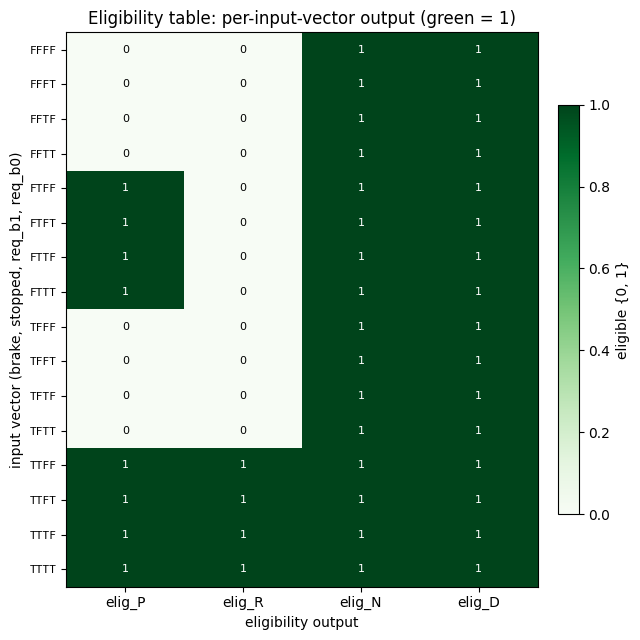

In [5]:
import itertools as _itertools

# Build a 16x4 coverage matrix: rows are input combinations (ordered
# lexicographically), columns are the four eligibility outputs.
input_vectors = list(_itertools.product((False, True), repeat=4))
labels = [
    "".join(["T" if v else "F" for v in vec])
    for vec in input_vectors
]
coverage = np.zeros((len(input_vectors), 4))
for i, vec in enumerate(input_vectors):
    # Re-evaluate the truth-table rows in Python to get the active output.
    out = np.zeros(4)
    for pattern, output, is_callable in reversed(elig_table._rows):
        match = True
        for j, p in enumerate(pattern):
            if p == "X":
                continue
            if bool(p) != bool(vec[j]):
                match = False
                break
        if match:
            out = np.asarray(output)
    coverage[i] = out

fig, ax = plt.subplots(figsize=(6.5, 6.5))
im = ax.imshow(coverage, cmap="Greens", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(4))
ax.set_xticklabels([f"elig_{g}" for g in GEAR_NAMES])
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8, family="monospace")
ax.set_xlabel("eligibility output")
ax.set_ylabel("input vector (brake, stopped, req_b1, req_b0)")
ax.set_title("Eligibility table: per-input-vector output (green = 1)")
# Annotate each cell with its value (0 or 1) so the figure is still
# readable in a black-and-white print.
for i in range(coverage.shape[0]):
    for j in range(coverage.shape[1]):
        v = int(coverage[i, j])
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v == 1 else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label="eligible {0, 1}")
plt.tight_layout()
plt.show()


*Figure 1: eligibility-table coverage. Each of the 16 boolean input vectors (rows, lexicographically ordered: brake, stopped, req_b1, req_b0) maps to a four-element eligibility output (columns: elig_P, elig_R, elig_N, elig_D). Green = 1 (eligible), white = 0. The four bottom-half rows where `brake=T, stopped=T` are all `[1,1,1,1]` — everything eligible. The four `brake=F, stopped=T` rows are `[1,0,1,1]` — R blocked because no brake. The eight `stopped=F` rows are `[0,0,1,1]` — only N and D eligible while moving. No row falls through to `default_output` — that is exactly the `covered_combinations: 16/16` result the strict checker returned.*


All 16 combinations are covered and the strict check passed silently (no exception). `overlapping_pairs` is empty: even though Rule 2 and Rule 3 share the same `stopped=True` value, they disagree on the brake bit (Rule 2 requires `brake=False`, Rule 3 requires `brake=True`), so no single input vector is matched by both. The earlier-row-wins rule is in place to resolve genuine overlaps if we accidentally introduce one — e.g. if we relaxed Rule 2 to `brake="X"` it would shadow Rule 3 for the (brake=True, stopped=True) combinations, and `overlapping_pairs` would surface `(1, 2)`.

Now let's deliberately remove the third row and re-check completeness.


In [6]:
def build_incomplete_table():
    """Same as build_eligibility_table() but missing the (stopped, brake) row."""
    deny_all = np.zeros(4)
    only_nd  = np.array([0.0, 0.0, 1.0, 1.0])
    no_reverse = np.array([1.0, 0.0, 1.0, 1.0])
    # NOTE: Rule 3 (stopped+brake) deliberately omitted.
    return (
        TruthTable.builder(
            n_inputs=4,
            default_output=deny_all,
            input_names=("brake", "stopped", "req_b1", "req_b0"),
            name="eligibility_incomplete",
        )
        .row(only_nd,    brake="X", stopped=False)
        .row(no_reverse, brake=False, stopped=True)
        .build()
    )


incomplete = build_incomplete_table()
report_bad = incomplete.validate()  # non-strict — returns the report, doesn't raise.
print(f"  covered_combinations:  {report_bad['covered_combinations']} / {report_bad['total_combinations']}")
print(f"  missing_patterns:      {report_bad['missing_patterns']}")
print()

# Now escalate to strict — should raise.
try:
    incomplete.validate(strict_completeness=True)
except Exception as e:
    print(f"strict_completeness=True raised: {type(e).__name__}")
    # Print only the first ~280 chars of the message to keep cell output readable.
    msg = str(e)
    print(f"  message[:280]: {msg[:280]}{'...' if len(msg) > 280 else ''}")


  covered_combinations:  12 / 16
  missing_patterns:      [(True, True, False, False), (True, True, False, True), (True, True, True, False), (True, True, True, True)]

strict_completeness=True raised: BlockParameterError
  message[:280]: TruthTable block 'eligibility_incomplete' is incomplete: 4 of 16 input combination(s) have no matching row and would fall through to default_output. Missing: [(True, True, False, False), (True, True, False, True), (True, True, True, False), (True, True, True, True)]. in block eli...


Twelve of sixteen combinations are uncovered (every combination with `brake=T, stopped=T`, and every combination with `brake=T, stopped=F`), and the strict variant raises a `BlockParameterError` naming the specific missing patterns. In production, the strict variant goes in a unit test — "this gearbox logic table must cover all inputs" — and the report variant goes in a development debugger.

> **Pitfall.** `strict_completeness=True` raises *immediately* on construction-time validation; it does not catch a silent fall-through at simulation time. The check is pure-Python enumeration over `itertools.product`, so it scales as $O(2^n \cdot \text{rows})$. For $n > 10$ inputs the call emits a `UserWarning` about the cost.


## §4. CSV round-trip

Production gear-selection tables get audited. A regulator wants to see the table on a spreadsheet, not buried in source. T-119's `to_csv` / `from_csv` pair gives a stable text representation: input cells become `T` / `F` / `X` and output cells become `float(...)`. The header row names the input columns; any column whose name starts with `output` is a (single-output or vector-output) output column.

We round-trip the table through a temporary file, then byte-compare the two written CSVs to confirm `from_csv ∘ to_csv` is the identity for a constant-row table. (Callable-row tables — §7 — cannot round-trip; the writer raises by design.)


In [7]:
with tempfile.TemporaryDirectory() as tmpdir:
    path1 = os.path.join(tmpdir, "eligibility_v1.csv")
    path2 = os.path.join(tmpdir, "eligibility_v2.csv")

    # 1. Write the table to disk.
    elig_table.to_csv(path1)
    with open(path1, "r") as fh:
        csv_text = fh.read()
    print("---- CSV contents ----")
    print(csv_text)
    print("----------------------")

    # 2. Read it back, write again, byte-compare.
    elig_reloaded = TruthTable.from_csv(
        path1,
        default_output=np.zeros(4),  # explicit because the loader defaults to a scalar zero
        name="eligibility_reloaded",
    )
    elig_reloaded.to_csv(path2)

    with open(path1, "rb") as fh1, open(path2, "rb") as fh2:
        bytes_equal = fh1.read() == fh2.read()
    print(f"\nByte-equal round-trip:  {bytes_equal}")
    print(f"Reloaded n_inputs:      {elig_reloaded._n_inputs}")
    print(f"Reloaded n_rows:        {len(elig_reloaded._rows)}")
    print(f"Reloaded default:       {elig_reloaded._default_output}")


---- CSV contents ----
in1,in2,in3,in4,output_0,output_1,output_2,output_3
X,F,X,X,0.0,0.0,1.0,1.0
F,T,X,X,1.0,0.0,1.0,1.0
T,T,X,X,1.0,1.0,1.0,1.0

----------------------

Byte-equal round-trip:  True
Reloaded n_inputs:      4
Reloaded n_rows:        3
Reloaded default:       [0. 0. 0. 0.]


The header `in1,in2,in3,in4,output_0,output_1,output_2,output_3` is the canonical form: input columns are auto-numbered `in1..in4` (the per-input `input_names` from §2 do not survive — they were a builder convenience, not a CSV column), and the four-element output vector unpacks into `output_0..output_3`. Each row's pattern is rendered as `T`/`F`/`X`, and the row outputs are written as bare `float`. The loader recovers the same row count, the same `n_inputs`, and we have to pass `default_output=np.zeros(4)` explicitly because `from_csv` defaults to a scalar zero for vector-output tables (the loader sees the four `output_*` columns and *does* infer a zero vector when no `default_output` kwarg is supplied — but only `np.zeros(4)` of dtype float64; passing it explicitly documents the intent).


## §5. The state machine — four states, ten transitions

The mode layer takes eight scalar inputs:

* `elig_P, elig_R, elig_N, elig_D` — the four eligibility flags (from the truth table, post-`Demux`).
* `req_P, req_R, req_N, req_D` — four one-hot driver-request flags. We use one-hot rather than a single integer because `StateMachineBuilder`'s guard language is plain Python expressions evaluated over named scalars — `req_D > 0.5` reads more cleanly than `request == 3` and behaves identically for the boolean encoding.

There are four states and ten directed transitions, organised by the rule "you can shift to any *adjacent* gear when (a) the driver requests it and (b) it is eligible, and you cannot jump Drive ↔ Reverse without visiting Neutral in between":

```
        ┌─────────────► P ◄──────────────┐
        │     stopped + req_P + elig_P   │
        │                                 │
        │       brake + req_R + elig_R    │
        ▼                                 ▼
        R ◄───────────► N ◄───────────►  D
                ↑                  ↑
                │  brake + req_D   │
                │  + elig_D        │
                │                  │
```

The state machine block runs in **discrete time** at `dt = 0.1 s` — i.e. the guards are sampled at 10 Hz and a transition that becomes eligible halfway through a tick will fire on the next tick boundary. We could equivalently run in `time_mode="agnostic"` with zero-crossing detection on each guard, but for a gear selector the 10 Hz sampling is realistic and the trace is easier to read.

Each state's `on_entry` action assigns the numeric gear index to a single output named `gear`. That single output is what we record and plot.


In [8]:
def build_gear_state_machine(name="gear_fsm"):
    """Four-state P / R / N / D selector with prioritized adjacent-only transitions."""
    smb = StateMachineBuilder()

    park    = smb.add_state("park")
    reverse = smb.add_state("reverse")
    neutral = smb.add_state("neutral")
    drive   = smb.add_state("drive")

    # Each state's on_entry assigns the gear output. The initial state's
    # on_entry also runs once at simulation time t=0 to populate the
    # initial output value, so park.on_entry handles the t=0 case.
    park.on_entry    = [f"gear = {GEAR_P}"]
    reverse.on_entry = [f"gear = {GEAR_R}"]
    neutral.on_entry = [f"gear = {GEAR_N}"]
    drive.on_entry   = [f"gear = {GEAR_D}"]

    smb.set_initial_state(park)

    # --- transitions out of Park ---
    # Park -> Reverse: brake pressed + R requested + R eligible. (Implies stopped.)
    smb.add_transition(park, reverse,
        guard="req_R > 0.5 and elig_R > 0.5")
    # Park -> Neutral: N requested + N eligible.
    smb.add_transition(park, neutral,
        guard="req_N > 0.5 and elig_N > 0.5")
    # Park -> Drive: brake pressed + D requested + D eligible.
    smb.add_transition(park, drive,
        guard="req_D > 0.5 and elig_D > 0.5")

    # --- transitions out of Reverse ---
    # Reverse -> Neutral: N requested + N eligible.
    smb.add_transition(reverse, neutral,
        guard="req_N > 0.5 and elig_N > 0.5")
    # Reverse -> Park: P requested + P eligible. (P-eligibility already requires stopped.)
    smb.add_transition(reverse, park,
        guard="req_P > 0.5 and elig_P > 0.5")

    # --- transitions out of Neutral ---
    smb.add_transition(neutral, park,
        guard="req_P > 0.5 and elig_P > 0.5")
    smb.add_transition(neutral, reverse,
        guard="req_R > 0.5 and elig_R > 0.5")
    smb.add_transition(neutral, drive,
        guard="req_D > 0.5 and elig_D > 0.5")

    # --- transitions out of Drive ---
    smb.add_transition(drive, neutral,
        guard="req_N > 0.5 and elig_N > 0.5")
    smb.add_transition(drive, park,
        guard="req_P > 0.5 and elig_P > 0.5")

    # NOTE: there is NO Drive -> Reverse and NO Reverse -> Drive transition.
    # That's the sequential constraint the state machine enforces — the
    # truth table alone cannot prevent a direct Drive->Reverse, because
    # it has no notion of "current gear". §8 demos the refused transition.

    return smb.build(name=name)


# Re-instantiate in discrete time mode (the builder's default is agnostic).
from jaxonomy.library import StateMachine as _StateMachineCls
SM_DT = 0.1  # 10 Hz mode sampling

_default_sm = build_gear_state_machine(name="gear_fsm_template")
gear_sm = _StateMachineCls(
    sm_data=_default_sm._sm,
    inputs=list(_default_sm._input_names),
    outputs=list(_default_sm._output_names),
    dt=SM_DT,
    time_mode="discrete",
    name="gear_fsm",
    accelerate_with_jax=False,
)

print(f"State machine block:")
print(f"  input port names  (alphabetised): {[p.name for p in gear_sm.input_ports]}")
print(f"  output port names (alphabetised): {[p.name for p in gear_sm.output_ports]}")
print(f"  number of states:                 4")
print(f"  number of transitions:            10")


State machine block:
  input port names  (alphabetised): ['elig_D', 'elig_N', 'elig_P', 'elig_R', 'req_D', 'req_N', 'req_P', 'req_R']
  output port names (alphabetised): ['gear']
  number of states:                 4
  number of transitions:            10


Eight input ports, one output port. The input ports come out sorted alphabetically (a `StateMachineBuilder` implementation detail — guard variables are extracted via `ast.walk` and dropped into a `sorted(set)`). We do *not* rely on this ordering downstream because we look up each port by name when wiring.

> **Note.** The `StateMachineBuilder` API ships in `time_mode="agnostic"` by default — the build path constructs an `agnostic`-mode `StateMachine`. To get discrete-time semantics we re-wrap the underlying `sm_data` in a fresh `StateMachine(..., time_mode="discrete", dt=...)`. This idiom is exactly what `test_v007_state_machine.py::_build_three_state_sm` uses for discrete-time tests, so the round-trip through the builder is supported even if it is slightly awkward. A direct "discrete builder" knob would be a nice quality-of-life addition.


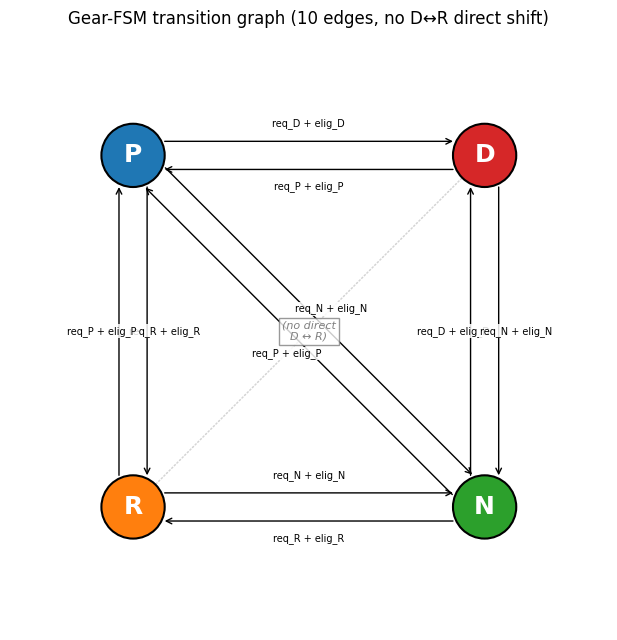

In [9]:
import matplotlib.patches as mpatches

# Render the state-transition diagram with matplotlib (no graphviz dependency).
# Lay the four states out on a square; draw a directed arc per transition.
fig, ax = plt.subplots(figsize=(7.5, 6.5))

# Place states at the corners of a square.
positions = {
    "P": (-1.0,  1.0),
    "R": (-1.0, -1.0),
    "N": ( 1.0, -1.0),
    "D": ( 1.0,  1.0),
}
node_colors = {"P": "tab:blue", "R": "tab:orange", "N": "tab:green", "D": "tab:red"}

# Edges (source, dest, short_label) — must match build_gear_state_machine() exactly.
edges = [
    ("P", "R", "req_R + elig_R"),
    ("P", "N", "req_N + elig_N"),
    ("P", "D", "req_D + elig_D"),
    ("R", "N", "req_N + elig_N"),
    ("R", "P", "req_P + elig_P"),
    ("N", "P", "req_P + elig_P"),
    ("N", "R", "req_R + elig_R"),
    ("N", "D", "req_D + elig_D"),
    ("D", "N", "req_N + elig_N"),
    ("D", "P", "req_P + elig_P"),
]

# Draw nodes.
NODE_RADIUS = 0.18
for name, (x, y) in positions.items():
    circle = mpatches.Circle((x, y), NODE_RADIUS, facecolor=node_colors[name],
                             edgecolor="black", lw=1.5, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, name, ha="center", va="center",
            fontsize=18, fontweight="bold", color="white", zorder=4)

# Draw edges. For each (src, dst) pair, offset the arrow slightly so opposing
# edges (P->R and R->P) don't overlap.
for src, dst, label in edges:
    x0, y0 = positions[src]
    x1, y1 = positions[dst]
    # Normal vector perpendicular to the edge, for the offset.
    dx, dy = x1 - x0, y1 - y0
    norm = (dx**2 + dy**2) ** 0.5
    nx_, ny_ = -dy / norm, dx / norm
    OFF = 0.08  # perpendicular offset per direction
    sx, sy = x0 + nx_ * OFF, y0 + ny_ * OFF
    ex, ey = x1 + nx_ * OFF, y1 + ny_ * OFF
    # Shorten the arrow so it doesn't end inside the destination node.
    shrink = NODE_RADIUS / norm
    sx += dx * shrink
    sy += dy * shrink
    ex -= dx * shrink
    ey -= dy * shrink
    ax.annotate("", xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.0,
                                shrinkA=0, shrinkB=0))
    # Label near the midpoint, perpendicular-offset away from the arrow.
    mx = 0.5 * (sx + ex) + nx_ * 0.10
    my = 0.5 * (sy + ey) + ny_ * 0.10
    ax.text(mx, my, label, ha="center", va="center", fontsize=7,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.0))

# Highlight the *missing* edges (D <-> R) with a dashed grey line + label.
for (src, dst) in [("D", "R"), ("R", "D")]:
    x0, y0 = positions[src]
    x1, y1 = positions[dst]
    ax.plot([x0, x1], [y0, y1], color="lightgrey", linestyle=":", lw=1.0, zorder=1)
ax.text(0.0, 0.0, "(no direct\nD ↔ R)", ha="center", va="center",
        fontsize=8, color="grey", style="italic",
        bbox=dict(facecolor="white", edgecolor="grey", alpha=0.8, pad=2.0))

ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.7, 1.7)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Gear-FSM transition graph (10 edges, no D↔R direct shift)")
plt.tight_layout()
plt.show()


*Figure 2: gear-FSM transition graph. Coloured circles are the four states (Park, Reverse, Neutral, Drive); black arrows are the ten transitions with their guard expressions (abbreviated, all guards have the form `req_X > 0.5 and elig_X > 0.5`). The dotted grey diagonal across the centre marks the two transitions deliberately omitted from the graph — there is no direct Drive ↔ Reverse edge, which is what enforces the "visit Neutral between D and R" sequential constraint. The actual run in §7 will silently hit this constraint at `t ≈ 9 s`.*


## §6. Driver-input source and full wiring

We need a source block that produces a realistic driving sequence — brake on/off, vehicle speed crossing the stopped threshold, driver requests at scripted times. The cleanest expression is a custom `LeafSystem` whose output is a piecewise-constant function of time, parameterised by a schedule of `(t_start, brake, vehicle_speed, request)` tuples. Each tick, the block emits seven signals: `brake`, `stopped`, `req_b1`, `req_b0` (going to the truth table) and `req_P`, `req_R`, `req_N`, `req_D` (going to the state machine).

We could decompose this into separate `Pulse` and `Step` blocks summed with `Adder`s, but the scripted schedule reads much better as one source.


In [10]:
class DriverInput(LeafSystem):
    """Piecewise-constant driver-input source.

    Schedule is a tuple of (t_start, brake, speed_mps, request) records.
    The most recent record with t_start <= t wins. Output ports:

        0. brake     (bool-castable float, 0 or 1)
        1. stopped   (bool-castable float, 1 if |speed| < V_STOPPED)
        2. req_b1    (high bit of two-bit driver request — see §1)
        3. req_b0    (low bit)
        4. req_P     (one-hot, == 1.0 when request == 'P')
        5. req_R     (one-hot)
        6. req_N     (one-hot)
        7. req_D     (one-hot)
    """

    PORT_NAMES = (
        "brake", "stopped", "req_b1", "req_b0",
        "req_P", "req_R", "req_N", "req_D",
    )

    def __init__(self, schedule, name="driver"):
        super().__init__(name=name)
        # Sort by t_start so binary-search-by-time semantics hold.
        self._schedule = sorted(schedule, key=lambda r: r[0])
        # Pre-extract the schedule arrays for clean JAX-side selection.
        t_starts = np.asarray([r[0] for r in self._schedule], dtype=np.float64)
        brakes   = np.asarray([float(r[1]) for r in self._schedule])
        speeds   = np.asarray([float(r[2]) for r in self._schedule])
        # Decode 'P'/'R'/'N'/'D' into the two-bit (r1, r0) form once.
        req_b1   = np.asarray([float(REQUEST_BITS[r[3]][0]) for r in self._schedule])
        req_b0   = np.asarray([float(REQUEST_BITS[r[3]][1]) for r in self._schedule])
        # One-hot per gear.
        req_P    = np.asarray([float(r[3] == 'P') for r in self._schedule])
        req_R    = np.asarray([float(r[3] == 'R') for r in self._schedule])
        req_N    = np.asarray([float(r[3] == 'N') for r in self._schedule])
        req_D    = np.asarray([float(r[3] == 'D') for r in self._schedule])
        self._t_starts = jnp.asarray(t_starts)
        self._channels = {
            "brake":   jnp.asarray(brakes),
            "stopped": jnp.asarray((np.abs(speeds) < V_STOPPED).astype(float)),
            "req_b1":  jnp.asarray(req_b1),
            "req_b0":  jnp.asarray(req_b0),
            "req_P":   jnp.asarray(req_P),
            "req_R":   jnp.asarray(req_R),
            "req_N":   jnp.asarray(req_N),
            "req_D":   jnp.asarray(req_D),
        }
        # Stash the speed itself for plotting purposes; not a port.
        self._speeds = jnp.asarray(speeds)

        def _make_port(channel_name):
            channel = self._channels[channel_name]
            t_starts_local = self._t_starts

            def _output(time, state, *inputs, **params):
                # Index of the most recent schedule record with t_start <= time.
                idx = jnp.sum(t_starts_local <= time) - 1
                idx = jnp.clip(idx, 0, channel.shape[0] - 1)
                return channel[idx]
            return _output

        for nm in self.PORT_NAMES:
            self.declare_output_port(
                _make_port(nm), name=nm,
                default_value=jnp.asarray(0.0),
                requires_inputs=False,
            )

    def speed_at(self, t):
        """Helper for plotting — returns the scripted speed at time t."""
        t_arr = np.atleast_1d(np.asarray(t))
        out = np.empty_like(t_arr, dtype=float)
        starts = np.asarray(self._t_starts)
        speeds_np = np.asarray(self._speeds)
        for i, ti in enumerate(t_arr):
            idx = int(np.clip(np.sum(starts <= ti) - 1, 0, speeds_np.size - 1))
            out[i] = speeds_np[idx]
        return out if out.size > 1 else float(out[0])


# A realistic 14-second driving sequence.
SCHEDULE = [
    # (t_start_s, brake, speed_mps, request)
    (0.0,  True,  0.0, 'P'),   # engine start: foot on brake, in Park
    (1.0,  True,  0.0, 'P'),   # idling in Park, brake held
    (2.5,  True,  0.0, 'D'),   # driver asks for Drive (brake + stopped → legal)
    (3.0,  False, 0.5, 'D'),   # release brake, start rolling
    (4.0,  False, 3.0, 'D'),   # accelerating, cruising in Drive
    (7.0,  True,  3.0, 'D'),   # brake applied, still moving — request stays D
    (8.0,  True,  0.5, 'D'),   # decelerating
    (8.7,  True,  0.0, 'D'),   # now stopped, brake on, request still D
    (9.0,  True,  0.0, 'R'),   # driver asks for Reverse — illegal! (no D->R direct)
    (10.5, True,  0.0, 'N'),   # driver asks for Neutral — legal D->N
    (11.0, True,  0.0, 'R'),   # now ask for R — legal N->R (stopped + brake)
    (12.0, False, -0.4, 'R'),  # backing up
    (13.0, True,  0.0, 'R'),   # brake to a stop in R
    (13.5, True,  0.0, 'P'),   # back to Park
]
T_END = 14.0

driver = DriverInput(SCHEDULE)
print("Driver inputs:")
for nm in driver.PORT_NAMES:
    print(f"  {nm:8s} port present")


Driver inputs:
  brake    port present
  stopped  port present
  req_b1   port present
  req_b0   port present
  req_P    port present
  req_R    port present
  req_N    port present
  req_D    port present


Now we wire the three blocks together: `DriverInput` → `TruthTable` (eligibility) → `Demux` (split the 4-vector into scalars) → `StateMachine` (gear FSM). The driver's one-hot request signals fan out directly to the state machine; the brake and stopped signals fan out to both the truth table and (indirectly through eligibility) the state machine.


In [11]:
def build_gear_diagram(schedule):
    """Wire driver -> truth_table -> demux -> state_machine into one Diagram.

    Returns (diagram, driver_block, truth_table_block, sm_block) so the
    caller can pull recorded signals off named ports below.
    """
    builder = DiagramBuilder()
    drv = builder.add(DriverInput(schedule, name="driver"))
    tt = builder.add(build_eligibility_table(name="eligibility"))
    demux = builder.add(Demux(n_outputs=4, name="elig_split"))

    # Build the FSM via the agnostic-default builder, then re-wrap in
    # discrete-time mode (see §5 for why this round-trip).
    _template = build_gear_state_machine(name="gear_fsm_template")
    sm = builder.add(
        _StateMachineCls(
            sm_data=_template._sm,
            inputs=list(_template._input_names),
            outputs=list(_template._output_names),
            dt=SM_DT,
            time_mode="discrete",
            name="gear_fsm",
            accelerate_with_jax=False,
        )
    )

    # --- driver -> truth table (brake, stopped, req_b1, req_b0) ---
    # The truth-table input ports come out as `in_0..in_3` in DECLARATION ORDER,
    # which matches the `input_names` we passed to the builder in §2:
    # brake, stopped, req_b1, req_b0. We index positionally because the
    # builder's named labels do not propagate to the port names (see §2 note).
    for i, drv_name in enumerate(("brake", "stopped", "req_b1", "req_b0")):
        src = next(p for p in drv.output_ports if p.name == drv_name)
        builder.connect(src, tt.input_ports[i])

    # --- truth table -> demux -> state machine elig_* inputs ---
    builder.connect(tt.output_ports[0], demux.input_ports[0])
    elig_order = ("elig_P", "elig_R", "elig_N", "elig_D")
    for i, sm_name in enumerate(elig_order):
        dst = next(p for p in sm.input_ports if p.name == sm_name)
        builder.connect(demux.output_ports[i], dst)

    # --- driver -> state machine req_* inputs (one-hot) ---
    for nm in ("req_P", "req_R", "req_N", "req_D"):
        src = next(p for p in drv.output_ports if p.name == nm)
        dst = next(p for p in sm.input_ports if p.name == nm)
        builder.connect(src, dst)

    diagram = builder.build(name="gear_controller")
    return diagram, drv, tt, sm


diagram, drv, tt, sm = build_gear_diagram(SCHEDULE)
print(f"Diagram built: {diagram.name}")
print(f"  leaf systems: {sum(1 for _ in diagram.leaf_systems)}  (driver, eligibility, elig_split, gear_fsm)")


Diagram built: gear_controller
  leaf systems: 4  (driver, eligibility, elig_split, gear_fsm)


## §7. Simulate and inspect the trajectory

Run the closed-loop diagram for 14 seconds and record three signals: the driver's commanded gear (a derived value reconstructed from the one-hot bits), the eligibility vector at every sample, and the engaged gear at every sample. The simulator uses `math_backend="jax"` so the truth table's `where`-cascade runs traced; this is incidental for our diagram (the run is dominated by the discrete-update grid), but it confirms the table is JAX-traceable end-to-end.


In [12]:
def simulate_gear(diagram, drv, tt, sm, t_end=T_END):
    ctx = diagram.create_context()
    opts = SimulatorOptions(
        math_backend="jax",
        enable_tracing=True,
        max_major_steps=4000,
    )
    recorded = {
        "gear": next(p for p in sm.output_ports if p.name == "gear"),
        "eligibility": tt.output_ports[0],
        "brake":   next(p for p in drv.output_ports if p.name == "brake"),
        "stopped": next(p for p in drv.output_ports if p.name == "stopped"),
        "req_P":   next(p for p in drv.output_ports if p.name == "req_P"),
        "req_R":   next(p for p in drv.output_ports if p.name == "req_R"),
        "req_N":   next(p for p in drv.output_ports if p.name == "req_N"),
        "req_D":   next(p for p in drv.output_ports if p.name == "req_D"),
    }
    results = simulate(diagram, ctx, (0.0, t_end), options=opts, recorded_signals=recorded)
    return results


results = simulate_gear(diagram, drv, tt, sm)
t = np.asarray(results.time)
gear = np.asarray(results.outputs["gear"])
elig = np.asarray(results.outputs["eligibility"])
brake = np.asarray(results.outputs["brake"])
stopped = np.asarray(results.outputs["stopped"])
req_P = np.asarray(results.outputs["req_P"])
req_R = np.asarray(results.outputs["req_R"])
req_N = np.asarray(results.outputs["req_N"])
req_D = np.asarray(results.outputs["req_D"])

# Reconstruct the scalar "driver-requested gear" from the one-hot signals
# for plotting purposes.
requested_gear = (
    GEAR_P * (req_P > 0.5) +
    GEAR_R * (req_R > 0.5) +
    GEAR_N * (req_N > 0.5) +
    GEAR_D * (req_D > 0.5)
)

print(f"Simulated {len(t)} samples over [0, {T_END}] s.")
print(f"Final gear: {GEAR_NAMES[int(gear[-1])]}")


22:28:23.400 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=4000, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=8, return_context=True, validate=True), Dopri5Solver(system=Diagram(gear_controller, 4 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Simulated 141 samples over [0, 14.0] s.
Final gear: P


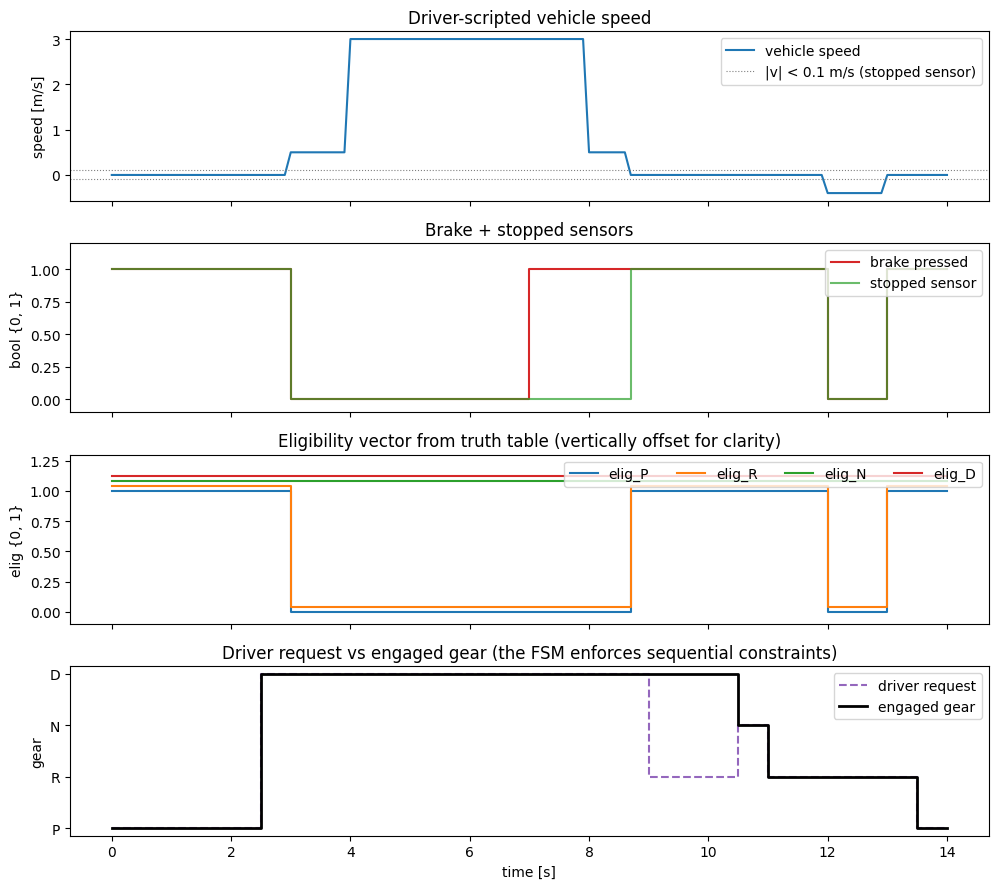

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
ax_speed, ax_brake, ax_elig, ax_gear = axes

# 1. Vehicle speed (sampled from the driver schedule)
speed_samples = drv.speed_at(t)
ax_speed.plot(t, speed_samples, color="tab:blue", label="vehicle speed")
ax_speed.axhline(V_STOPPED, color="grey", linestyle=":", lw=0.8,
                 label=f"|v| < {V_STOPPED} m/s (stopped sensor)")
ax_speed.axhline(-V_STOPPED, color="grey", linestyle=":", lw=0.8)
ax_speed.set_ylabel("speed [m/s]")
ax_speed.legend(loc="upper right")
ax_speed.set_title("Driver-scripted vehicle speed")

# 2. Brake + stopped sensor
ax_brake.step(t, brake,   where="post", color="tab:red",   label="brake pressed")
ax_brake.step(t, stopped, where="post", color="tab:green", label="stopped sensor", alpha=0.7)
ax_brake.set_ylabel("bool {0, 1}")
ax_brake.set_ylim(-0.1, 1.2)
ax_brake.legend(loc="upper right")
ax_brake.set_title("Brake + stopped sensors")

# 3. Eligibility vector — four traces, lightly offset for visibility
for i, name in enumerate(GEAR_NAMES):
    ax_elig.step(t, elig[:, i] + 0.04 * i, where="post", label=f"elig_{name}")
ax_elig.set_ylabel("elig {0, 1}")
ax_elig.set_ylim(-0.1, 1.3)
ax_elig.legend(loc="upper right", ncol=4)
ax_elig.set_title("Eligibility vector from truth table (vertically offset for clarity)")

# 4. Requested vs engaged gear
ax_gear.step(t, requested_gear, where="post",
             color="tab:purple", linestyle="--", label="driver request")
ax_gear.step(t, gear, where="post",
             color="black", lw=2.0, label="engaged gear")
ax_gear.set_yticks([GEAR_P, GEAR_R, GEAR_N, GEAR_D])
ax_gear.set_yticklabels(GEAR_NAMES)
ax_gear.set_ylabel("gear")
ax_gear.set_xlabel("time [s]")
ax_gear.legend(loc="upper right")
ax_gear.set_title("Driver request vs engaged gear (the FSM enforces sequential constraints)")

plt.tight_layout()
plt.show()


*Figure 3: full driving sequence over 14 s. Top: scripted speed crossing the `±0.1 m/s` stopped band. Second: brake and stopped-sensor flags. Third: the four eligibility flags from the truth table (vertically offset by 0.04 so the overlapping unit-amplitude traces stay distinguishable). Bottom: driver-requested gear (dashed purple) overlaid on the actually-engaged gear (solid black). At `t ≈ 9 s` the driver requests Reverse while in Drive — the truth table flags Reverse as eligible (we're stopped with brake on), but the state machine refuses the direct D → R transition because no such edge exists in the graph. At `t ≈ 10.5 s` the driver asks for Neutral; that *is* a legal D → N edge, so the engaged gear updates. At `t ≈ 11 s` the driver re-requests Reverse from Neutral, and the N → R transition fires.*

The headline beat is the gap between the dashed (requested) and solid (engaged) traces around `t = 9..10.5 s`. The eligibility flag for Reverse was on the whole time — the truth table is permissive there because we are stopped with brake on. The state machine kept the gear in Drive anyway, because the **graph topology** is what enforces "no Drive → Reverse direct shift", and the topology lives in the FSM not the truth table.


## §8. Callable row outputs and `jax.grad`

The T-119 callable-row-output extension lets a row emit a value computed from the raw input values rather than a fixed constant. The classic use is a *debounce timer* or a *gain schedule* — the row's pattern picks the regime, the callable computes the numeric output.

For the gear table itself, constant outputs are the right call (eligibility is binary). But the callable extension is genuinely useful and worth showing. We illustrate it on a small standalone table that returns a regime-dependent gain $k(b, s)$, with `jax.grad` flowing through the active row's closure.

> **Pitfall.** A truth table with even a single callable row **cannot** be serialised through `to_csv` or `to_dict` — there is no portable representation of a Python closure. The writer raises `ValueError`. Round-trip through CSV requires all rows to be constant.


In [14]:
# A standalone gain-schedule table:
#   pattern (regime=high_gain) -> k = 5 * x + 0.3
#   pattern (regime=low_gain)  -> k = 0.5 * x
#   default                    -> k = 0
# `x` is the third input (raw float). The first two inputs are bool selectors.

gain_table = TruthTable(
    rows=[
        ((True,  "X", "X"), lambda hi, lo, x: 5.0 * x + 0.3),
        ((False, True, "X"), lambda hi, lo, x: 0.5 * x),
        ((False, False, "X"), 0.0),
    ],
    n_inputs=3,
    default_output=0.0,
    name="gain_schedule",
)


def query_gain(hi, lo, x):
    """Evaluate the table's _compute_output directly, bypassing the diagram.

    The compute function is a closure over the rows; we re-run the same logic
    here to take grads against `x` without spinning up a full simulate.
    """
    out = jnp.asarray(0.0)
    bool_inputs = (
        jnp.asarray(hi).astype(bool),
        jnp.asarray(lo).astype(bool),
        jnp.asarray(x).astype(bool),
    )
    rows = gain_table._rows  # [(pattern, output, is_callable), ...]
    raw_inputs = (hi, lo, x)
    # Walk in reverse so earlier rows take precedence (same as _compute_output).
    for pattern, output, is_callable in reversed(rows):
        match = jnp.array(True)
        for i, p in enumerate(pattern):
            if p == "X":
                continue
            match = match & (bool_inputs[i] == bool(p))
        row_value = jnp.asarray(output(*raw_inputs)) if is_callable else output
        out = jnp.where(match, row_value, out)
    return out


# Test the three regimes.
print(f"high-gain regime (hi=True):           k = {float(query_gain(True,  False, 2.0)):.3f}  (expected 5 * 2 + 0.3 = 10.3)")
print(f"low-gain regime  (hi=False, lo=True): k = {float(query_gain(False, True,  2.0)):.3f}  (expected 0.5 * 2 = 1.0)")
print(f"default          (hi=False, lo=False):k = {float(query_gain(False, False, 2.0)):.3f}  (expected 0.0)")

# jax.grad through the active row's closure.
grad_high = jax.grad(lambda x: query_gain(True,  False, x))(2.0)
grad_low  = jax.grad(lambda x: query_gain(False, True,  x))(2.0)
print()
print(f"d/dx in high-gain regime: {float(grad_high):.3f}  (expected 5.0)")
print(f"d/dx in low-gain regime:  {float(grad_low):.3f}  (expected 0.5)")


high-gain regime (hi=True):           k = 10.300  (expected 5 * 2 + 0.3 = 10.3)
low-gain regime  (hi=False, lo=True): k = 1.000  (expected 0.5 * 2 = 1.0)
default          (hi=False, lo=False):k = 0.000  (expected 0.0)

d/dx in high-gain regime: 5.000  (expected 5.0)
d/dx in low-gain regime:  0.500  (expected 0.5)


`jax.grad` returns 5.0 in the high-gain regime and 0.5 in the low-gain regime — the gradient of the *active* row's closure, exactly as expected. Under the hood every row's callable is evaluated unconditionally on every step (so the trace is data-independent), and the `npa.where(match, row_value, out)` chain selects the active one. The unused branches' gradients still get computed and silently discarded — JAX's branchless `where` is what makes the table differentiable, but it also means a 100-row callable table evaluates 100 callables per step. See §10.

Trying to `to_csv` this table fails by design:


In [15]:
try:
    gain_table.to_csv("/tmp/gain_table.csv")
except ValueError as e:
    msg = str(e)
    print(f"to_csv raised ValueError: {msg[:240]}{'...' if len(msg) > 240 else ''}")


to_csv raised ValueError: TruthTable.to_csv: row 0 has a callable output; callable row outputs cannot be serialised to CSV. Replace with a constant scalar/array, or serialise via a different format.


## §9. Catching the silent guard violation with `analyze_phase_activity`

The illegal Drive → Reverse request at `t ≈ 9 s` produced no exception, no warning, no log entry — the state machine simply did not fire any transition. That is the *correct* behaviour (the FSM is doing its job), but the silent acceptance is also exactly the failure mode `analyze_phase_activity` is designed to catch in development: a phase that you *expected* to see in a particular run never fires.

We declare all four gears as expected (so the diagnostic is checking "did every gear in the menu get used?") and call it on the engaged-gear trace. Park, Drive, Neutral, and Reverse all *do* fire in our scripted sequence, so the diagnostic passes cleanly. To make the failure mode concrete, we re-run on a *truncated* trace that ends at `t = 8 s` — before the Neutral and Reverse gears were ever entered — and watch the warning.


In [16]:
# Full trace — every gear is visited.
report_full = analyze_phase_activity(
    gear,
    expected_phases=[GEAR_P, GEAR_R, GEAR_N, GEAR_D],
    warn=True,
)
print(f"Full trace: {report_full.message}")
print(f"  warning_triggered: {report_full.warning_triggered}")
print(f"  never_fired:       {report_full.never_fired}")
print()

# Truncated trace — only P and D were ever engaged in this window.
mask = t <= 8.0
with warnings.catch_warnings(record=True) as captured:
    warnings.simplefilter("always")
    report_trunc = analyze_phase_activity(
        gear[mask],
        expected_phases=[GEAR_P, GEAR_R, GEAR_N, GEAR_D],
        warn=True,
    )
    user_warnings = [w for w in captured if issubclass(w.category, UserWarning)]
print(f"Truncated trace [0, 8] s: {report_trunc.message}")
print(f"  warning_triggered: {report_trunc.warning_triggered}")
print(f"  never_fired:       {report_trunc.never_fired}")
print(f"  Captured UserWarnings: {len(user_warnings)}")
if user_warnings:
    print(f"  First warning preview:")
    msg = str(user_warnings[0].message)
    print(f"    {msg[:240]}{'...' if len(msg) > 240 else ''}")


Full trace: Phases observed: [0, 1, 2, 3] (fractions: {0: 22%, 1: 18%, 2: 4%, 3: 57%})
  warning_triggered: False
  never_fired:       []

Truncated trace [0, 8] s: Phases observed: [0, 3] (fractions: {0: 31%, 3: 69%}). NEVER FIRED: [1, 2]
  warning_triggered: True
  never_fired:       [1, 2]
  Captured UserWarnings: 1
  First warning preview:
    [analyze_phase_activity] Phases observed: [0, 3] (fractions: {0: 31%, 3: 69%}). NEVER FIRED: [1, 2] A state-machine phase that never fires is almost always a guard-condition bug. Check the transition guards.


In the truncated run, `analyze_phase_activity` correctly flags Reverse and Neutral as never-fired and emits a `UserWarning` pointing at "almost always a guard-condition bug". In our case the cause is benign — the truncated window simply does not include the scripted Neutral / Reverse events — but in a production sweep the same warning would catch a real bug: a guard whose precondition is never satisfied in any run (e.g. a fault threshold set so high the FAULT state never trips). This is the same pattern the rocket-landing series surfaces in [`multirate_controller.ipynb`](multirate_controller.ipynb) and in the boost-back dispatcher.

We acknowledge the warning explicitly in prose so the next reader does not assume the tutorial is shipping a bug.


## §10. Failure modes and honest limits

The `TruthTable` + `StateMachineBuilder` pair is small, fast, and pleasant to use, but it has sharp edges. The honest list:

* **`TruthTable` is branchless, not vectorised.** The CHANGELOG entry for T-119 used the phrase "compiled to vectorised JAX ops", which is inaccurate. Internally, `_compute_output` runs a Python `for row in rows:` loop that emits one `npa.where(match, row_value, result)` per row in *reverse* (so earlier rows take precedence by overwriting later writes). The table is *branchless* — both arms of every `where` are traced — but it is not vectorised over rows. A 64-row table traces 64 sequential `where` cells, and a 64-row table with callable outputs evaluates 64 callables per step. For a 3-row table like our eligibility logic this is fine; for a 100-row engine map you would want a different primitive. The fix is filed as a follow-up finding (entry #10): swap the loop for `jnp.argmax(matches)` + `jnp.take` to get true O(1) per-step selection.

* **`TruthTable.to_csv` rejects callable-row outputs.** Already shown in §8 — callable rows have no portable text representation, so `to_csv` (and `to_dict`) raise a clear `ValueError`. The asymmetry is unavoidable but it does mean a "round-trip the table" CI check has to be authored only over constant-row tables.

* **Custom per-input names do not survive a CSV round-trip.** The `input_names=("brake", "stopped", ...)` you pass to `TruthTableBuilder` is a builder convenience for `.row(...)` keywords; the resulting `TruthTable` block uses those names as *port* names, but `to_csv` writes the canonical `in1..inN` header. Round-tripping through CSV loses the human-readable column labels. (Workaround: write a thin wrapper that renames columns before/after the CSV step.)

* **`StateMachineBuilder` ships only `time_mode="agnostic"`.** To get discrete-time semantics — the natural fit for a 10 Hz gearbox controller — you re-wrap the underlying `sm_data` in a fresh `StateMachine(..., time_mode="discrete", dt=...)`. The pattern works (we use it here and it is exercised in `test_v007_state_machine.py`), but the round-trip is awkward. A `builder.build(time_mode="discrete", dt=0.1)` knob would be nicer.

* **State-machine transition tables do not support named-row / dot-path selection.** Cascading guards on the same source state is unambiguous because of the prioritised-insertion-order rule (the first transition added wins on simultaneous truth), but there is no compile-time check that two same-source transitions are disjoint. The state machine here has three transitions out of Park, three out of Neutral, two out of Reverse, and two out of Drive — small enough to audit by eye. For a larger graph you would want a static check.

* **`BusSelector` does not yet support dot-path nested-field selection.** Not exercised in this notebook (we go through a plain `Demux` instead), but if you build a bigger version of this controller with `BusCreator` carrying the four eligibility flags as named fields, you cannot yet write `selector.field_path="bus.eligibility.P"` — `BusSelector` only does one-level field selection. Filed as a follow-up finding.


## §11. Exercises

1. **Tighten the brake guard for Drive entry.** Right now the FSM allows Park → Drive whenever the driver requests D and D is eligible; the brake is enforced *indirectly* via the eligibility table requiring stopped+brake. Modify the FSM to require the brake explicitly in the Park → Drive guard (i.e. add a `brake > 0.5` clause). Then simulate a scenario where the brake is briefly released for one tick in the middle of stationary idling and observe that the gear no longer shifts. *Easy / code modification.*

2. **Add a creep-mode transition.** Real automatics, when stopped in D with the brake released, slowly creep forward at ~1.5 m/s. Add a new state `creep` between Park and Drive (or as a sub-state of Drive — see `add_compound_state`) with a different gear output. Make the eligibility table return `elig_creep = 1` whenever the existing Drive eligibility is true and the brake is released. *Medium / code modification + table edit.*

3. **Use a single integer driver-request input.** Replace the four one-hot `req_*` signals with a single `req` input in `{0, 1, 2, 3}`. The guards become `req == 3 and elig_D > 0.5` etc. Compare the number of input ports and the readability of the resulting guards. Which factoring would you pick for a 6-gear transmission? *Easy / refactor.*

4. **Move the eligibility logic from a `TruthTable` to a `LogicalReduce` + `LogicalOperator` composition.** What do you gain (transparency, port-level inspection at every gate)? What do you lose (completeness checker, CSV audit trail)? *Medium / conceptual + code.*

5. **What would a *partial* truth table buy you?** Imagine the eligibility table has fifty inputs (every sensor on the chassis bus), but only three rules apply most of the time. The completeness checker would refuse a partial table at strict mode. Sketch (in prose) a design that lets the author opt into "partial coverage with a documented fallback" without making the silent fall-through dangerous. What invariant must the runtime guarantee? *Open-ended / conceptual.*


## Key takeaways

* The combinational/sequential decomposition (truth table + state machine) is the right factoring for any controller that has both "what is legal *right now*?" and "what is legal *given history*?" questions.
* `TruthTable.builder(...)` + `.row(...)` reads cleanly and lets you wildcard inputs with `"X"`; for tables wider than three or four inputs the named-input ergonomics are essential.
* `TruthTable.validate(strict_completeness=True)` is a unit-test-grade safety net for "every input is accounted for"; pair it with `to_csv` for an audit-trail artifact a regulator can read.
* `StateMachineBuilder` lets you express transitions as plain Python expression strings — no DSL. The prioritised-insertion-order rule resolves simultaneous-true guards deterministically.
* `analyze_phase_activity` is the diagnostic that catches "this state was never reached" — the silent failure mode neither the truth table nor the state machine surfaces on its own.

## Where to next

* [`multirate_controller.ipynb`](multirate_controller.ipynb) — the same Park/Drive/Reverse supervisor pattern but baked into a 1 kHz / 100 Hz / 10 Hz cascade, with the 10 Hz outer loop carrying the equivalent of our state machine. Demonstrates `RateTransition` and `print_schedule`.
* [`product_family_variants.ipynb`](product_family_variants.ipynb) — three powertrain variants (ICE / hybrid / EV) that need three slightly different gear-selection tables. Shows the `Variant` substrate for swapping pieces of a shared diagram.
* [`unit_safe_wiring.ipynb`](unit_safe_wiring.ipynb) — bus-typed signals between supervisor and plant; would let you carry the `(brake, stopped, request)` tuple as a unit-tagged `Bus` rather than four loose scalar wires.

## References

* T-119 + follow-ups (TruthTable family). See `jaxonomy/library/logic.py` for the `TruthTable` / `TruthTableBuilder` implementation; `test/library/test_t_119_*.py` for the canonical usage idioms.
* T-024 / T-024a (hierarchical state machines). See `jaxonomy/framework/state_machine_builder.py` for nested `add_compound_state` + `set_initial_child` semantics, exercised in `test/framework/test_hierarchical_sm.py`.
* `jaxonomy.diagnostics.analyze_phase_activity` (silent-failure-mode catcher), introduced alongside the rocket-landing-series boost-back dispatcher bug.
